<a href="https://colab.research.google.com/github/Clinton1029/Loan_Default_Project/blob/main/Loan_Default.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Comparative Analysis of Random Forest and XGBoost Classification Models for Loan Default Prediction

### Final Year Project

**Student:** Clinton Yade  
**Institution:** Dedan Kimathi University of Technology  
**Department:** Mathematics and Physical Sciences  
**Programme:** BSc in Mathematics and Modelling Processes

## 1. Introduction

Loan default prediction is an important application of machine learning in financial risk management.
Financial institutions need reliable methods for identifying borrowers who are likely to default on
their loans.

This project develops and compares two machine learning classification models, Random Forest and
XGBoost, for predicting loan default. The models will be trained using historical borrower and loan
information and evaluated using appropriate classification performance metrics.

## Problem Statement

Loan default is a major challenge for financial institutions, causing financial losses and poor credit risk management. Therefore, reliable machine learning models are needed to accurately predict loan default and support better lending decisions.

## 2. Project Workflow

The project will follow the following steps:

1. Import Required Libraries
2. Load the Dataset
3. Exploratory Data Analysis (EDA)
4. Data Preprocessing and Preparation
5. Feature Selection and Feature Importance
6. Split the Dataset into Training and Testing Sets
7. Choose the Machine Learning Models
8. Train the Machine Learning Models
9. Make Predictions
10. Evaluate Model Performance
11. Compare Random Forest and XGBoost
12. Predict Loan Default Outcome for New Borrowers

# 1. Import Required Libraries

The required Python libraries are imported to support data manipulation, data visualization,
data preprocessing, machine learning model development, and model evaluation.

In [1]:
# Import the os library for file and directory operations
import os

# Import pandas for data manipulation and analysis
import pandas as pd

# Import NumPy for numerical operations and array handling
import numpy as np

# Import Matplotlib for creating data visualizations and graphs
import matplotlib.pyplot as plt

# Import Matplotlib for creating data visualizations and graphs
import seaborn as sns

# Import the train_test_split function
from sklearn.model_selection import train_test_split

# Import the Random Forest classifier
from sklearn.ensemble import RandomForestClassifier

# Import the XGBoost classifier
from xgboost import XGBClassifier

# 2. Load the Dataset

The loan dataset is loaded into the Google Colab environment using Pandas.
The dataset will be used for exploratory data analysis, preprocessing, feature selection,
and development of the machine learning models.

In [2]:

# Define the path to the loan dataset
file_path = "/content/lending_club_loan_two.csv"

# Check if the file exists
if os.path.exists(file_path):
    print("File exists! Loading with pandas...")

    # Load the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    print("\nDataset loaded successfully!")

else:
    print("FILE DOESN'T EXIST")

File exists! Loading with pandas...

Dataset loaded successfully!


# 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the structure and characteristics of the loan dataset.
This stage involves examining the dataset dimensions, data types, missing values, duplicate records,
summary statistics, and the distribution of the target variable.

### 3.1 Preview of the Dataset

The first five records of the dataset are displayed to obtain an initial understanding of the available
variables and their values.

In [3]:
# Display the first five rows of the dataset
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


### 3.2 Preview of the Last Records

The last five records of the dataset are displayed to verify the end of the dataset and confirm that the data has been loaded correctly.

In [4]:
# Display the last five rows of the dataset
df.tail()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
41359,24000.0,60 months,15.59,578.42,C,C5,Superintendent,1 year,MORTGAGE,103000.0,...,13.0,0.0,24976.0,65.6,44.0,w,INDIVIDUAL,3.0,0.0,"53849 Hayden Springs Apt. 584\r\nPort Anthony,..."
41360,20950.0,60 months,17.27,523.71,C,C5,Wells Fargo Advisors,10+ years,MORTGAGE,47000.0,...,15.0,0.0,13067.0,44.6,33.0,f,INDIVIDUAL,3.0,0.0,"15220 Joyce Meadows\r\nPort Janetborough, MN 2..."
41361,4000.0,36 months,12.29,133.42,C,C1,MACHINE SPECIALIST,1 year,MORTGAGE,35000.0,...,11.0,1.0,6326.0,84.0,38.0,f,INDIVIDUAL,3.0,1.0,"554 Eric Prairie Apt. 260\r\nHannahhaven, DC 3..."
41362,8000.0,36 months,8.39,252.14,B,B1,"Loan Workout Support Specialist, Sr",10+ years,MORTGAGE,64000.0,...,10.0,1.0,2751.0,20.7,28.0,w,INDIVIDUAL,3.0,0.0,Unit 9898 Box 0142\r\nDPO AA 70466
41363,10000.0,36 months,11.67,330.57,B,B4,Sourcing Manager,10+ years,MORTGAGE,93000.0,...,9.0,0.0,11557.0,59.3,18.0,w,INDIVIDUAL,6.0,0.0,NaN


### 3.3 Dataset Dimensions

The number of rows and columns in the dataset is examined to determine its overall size.

In [5]:
# Display the number of rows and columns
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 41364
Number of columns: 27


### 3.4 Data Types and Dataset Information

The data types of the variables are examined to identify numerical and categorical features and to
understand the overall structure of the dataset.

In [6]:
# Display information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41364 entries, 0 to 41363
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   loan_amnt             41364 non-null  float64
 1   term                  41364 non-null  object 
 2   int_rate              41364 non-null  float64
 3   installment           41364 non-null  float64
 4   grade                 41364 non-null  object 
 5   sub_grade             41364 non-null  object 
 6   emp_title             39000 non-null  object 
 7   emp_length            39464 non-null  object 
 8   home_ownership        41364 non-null  object 
 9   annual_inc            41364 non-null  float64
 10  verification_status   41364 non-null  object 
 11  issue_d               41364 non-null  object 
 12  loan_status           41364 non-null  object 
 13  purpose               41364 non-null  object 
 14  title                 41198 non-null  object 
 15  dti                

### 3.5 Descriptive Statistics

Descriptive statistics are used to summarize the numerical variables in the dataset.
The summary includes measures such as count, mean, standard deviation, minimum, and maximum values.

In [7]:
# Display descriptive statistics for numerical variables
df.describe()

,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,41364.000000,41364.000000,41364.000000,4.136400e+04,41364.000000,41364.000000,41364.000000,41364.000000,41337.000000,41364.000000,37539.000000,41310.000000
mean,14120.261580,13.651636,431.998578,7.428202e+04,17.363288,11.309254,0.178609,15866.358403,53.864854,25.429576,1.805802,0.122150
std,8378.472648,4.462072,250.823082,5.947000e+04,8.200518,5.118044,0.511040,19690.335963,24.371407,11.844639,2.137853,0.358585
min,500.000000,5.320000,16.310000,2.500000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.940000,4.500000e+04,11.280000,8.000000,0.000000,6043.750000,36.000000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,376.190000,6.400000e+04,16.850000,10.000000,0.000000,11206.500000,55.000000,24.000000,1.000000,0.000000
75%,20000.000000,16.550000,566.585000,9.000000e+04,22.950000,14.000000,0.000000,19618.250000,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.740000,1533.810000,6.100000e+06,189.900000,51.000000,11.000000,617838.000000,129.400000,111.000000,34.000000,6.000000


### 3.6 Number of Unique Values

The number of unique values in each variable is examined to understand the diversity of the dataset and identify variables that may contain categorical information or identifiers.

In [8]:
# Display the number of unique values in each column
df.nunique()

,0
loan_amnt,1222
term,2
int_rate,470
installment,17240
grade,7
sub_grade,35
emp_title,24520
emp_length,11
home_ownership,6
annual_inc,4601


### 3.7 Numerical Variables

The numerical variables are identified to understand which features contain continuous or discrete numerical information that can be used for analysis and machine learning.

In [9]:
# Display the names of numerical columns
numerical_columns = df.select_dtypes(include=np.number).columns

print("Numerical columns:")
print(numerical_columns.tolist())

Numerical columns:
['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'mort_acc', 'pub_rec_bankruptcies']


### 3.8 Categorical Variables

The categorical variables are identified to understand which features contain non-numerical information and may require encoding during data preprocessing.

In [10]:
# Display the names of categorical columns
categorical_columns = df.select_dtypes(include="object").columns

print("Categorical columns:")
print(categorical_columns.tolist())

Categorical columns:
['term', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'title', 'earliest_cr_line', 'initial_list_status', 'application_type', 'address']


### 3.9 Missing Values

The dataset is examined for missing values in each variable. This is important because missing observations may need to be handled during data preprocessing.

In [11]:
# Count the number of missing values in each column
df.isnull().sum()

,0
loan_amnt,0
term,0
int_rate,0
installment,0
grade,0
sub_grade,0
emp_title,2364
emp_length,1900
home_ownership,0
annual_inc,0


###### Missing Values Identified

The exploratory data analysis identified missing values in several variables, including `emp_title`,
`emp_length`, `title`, `revol_util`, `mort_acc`, and `pub_rec_bankruptcies`.

These missing values will not be handled during the exploratory analysis. They will be addressed during
the **Data Preprocessing and Preparation** stage using appropriate techniques to ensure that the dataset
is suitable for machine learning.

### 3.9.1 Duplicate Records

The dataset is checked for duplicate records to identify repeated observations that may affect the analysis and model performance.

In [12]:
# Count the number of duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


###### Duplicate Records

The dataset was examined for duplicate records, and no duplicate observations were identified.
Therefore, no duplicate records need to be removed during the data preprocessing stage.

### 3.8 Loan Status Distribution

The distribution of loan status is visualized to understand the different loan outcomes and identify whether the target variable is balanced or imbalanced.

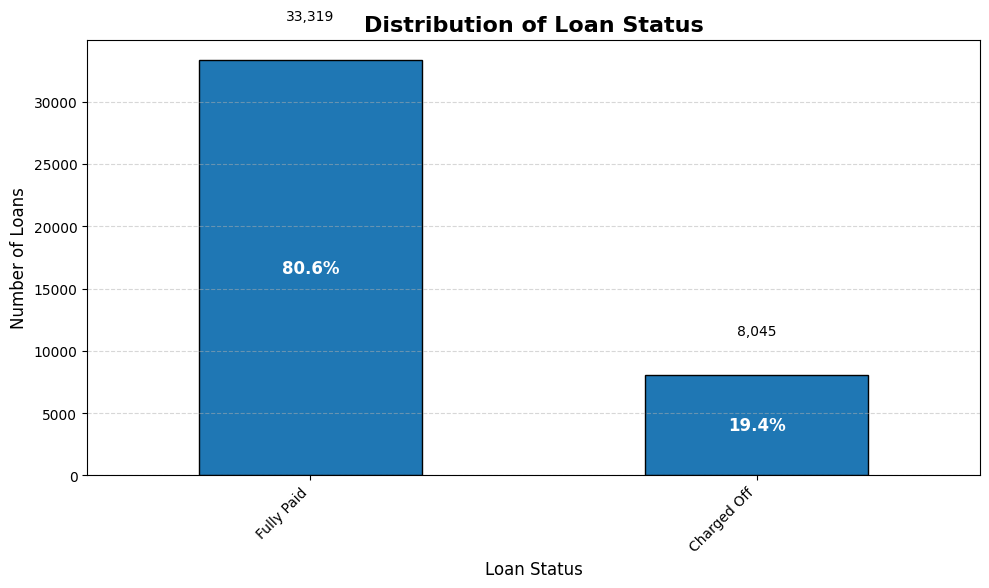

In [13]:
# Calculate the loan status counts
loan_status_counts = df["loan_status"].value_counts()

# Calculate the percentage of each loan status
loan_status_percentages = (loan_status_counts / loan_status_counts.sum()) * 100

# Create the figure
plt.figure(figsize=(10, 6))

# Create the bar chart
ax = loan_status_counts.plot(
    kind="bar",
    edgecolor="black"
)

# Add title and axis labels
plt.title("Distribution of Loan Status", fontsize=16, fontweight="bold")
plt.xlabel("Loan Status", fontsize=12)
plt.ylabel("Number of Loans", fontsize=12)

# Rotate x-axis labels
plt.xticks(rotation=45, ha="right")

# Add horizontal grid lines
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add count and percentage labels
for i, (count, percentage) in enumerate(
    zip(loan_status_counts, loan_status_percentages)
):
    # Add the percentage inside the bar
    ax.text(
        i,
        count / 2,
        f"{percentage:.1f}%",
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold",
        color="white"
    )

    # Add the exact count above the bar
    ax.text(
        i,
        count + 3000,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10
    )

# Adjust the layout
plt.tight_layout()

# Display the visualization
plt.show()

###### Interpretation

The distribution of loan status shows that 318,357 loans (approximately 80.4%) were fully paid, while 77,673 loans (approximately 19.6%) were charged off. This indicates that the target variable is imbalanced, with fully paid loans representing the majority class and charged-off loans representing the minority class.

The class imbalance will be considered during the data preprocessing and model development stages to ensure that the machine learning models are evaluated appropriately, particularly in their ability to identify charged-off loans.

### 3.9 Loan Amount Distribution

The distribution of loan amounts is visualized to understand the range and frequency of loan amounts issued to borrowers.

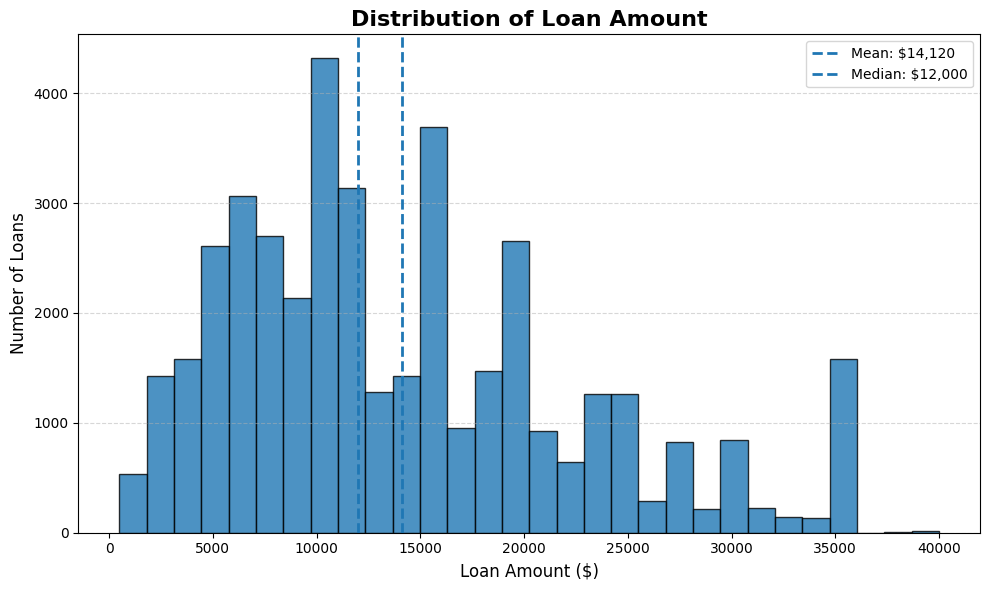

In [14]:
# Calculate the mean and median loan amounts
mean_loan = df["loan_amnt"].mean()
median_loan = df["loan_amnt"].median()

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the distribution of loan amounts
plt.hist(
    df["loan_amnt"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# Add a vertical line for the mean
plt.axvline(
    mean_loan,
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_loan:,.0f}"
)

# Add a vertical line for the median
plt.axvline(
    median_loan,
    linestyle="--",
    linewidth=2,
    label=f"Median: ${median_loan:,.0f}"
)

# Add title and axis labels
plt.title(
    "Distribution of Loan Amount",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Loan Amount ($)", fontsize=12)
plt.ylabel("Number of Loans", fontsize=12)

# Add grid lines
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Add legend
plt.legend()

# Adjust the layout
plt.tight_layout()

# Display the visualization
plt.show()

###### Interpretation

The loan amount distribution shows that most loans are concentrated between approximately $5,000 and $20,000. The mean loan amount is $14,114, while the median is $12,000. Since the mean is higher than the median, the distribution is positively skewed, indicating the presence of relatively larger loan amounts. Overall, the distribution shows considerable variation in the amounts borrowed by customers.

### 3.10 Distribution of Interest Rates

The distribution of interest rates is visualized to examine the range, frequency, and overall pattern of interest rates associated with the loans.

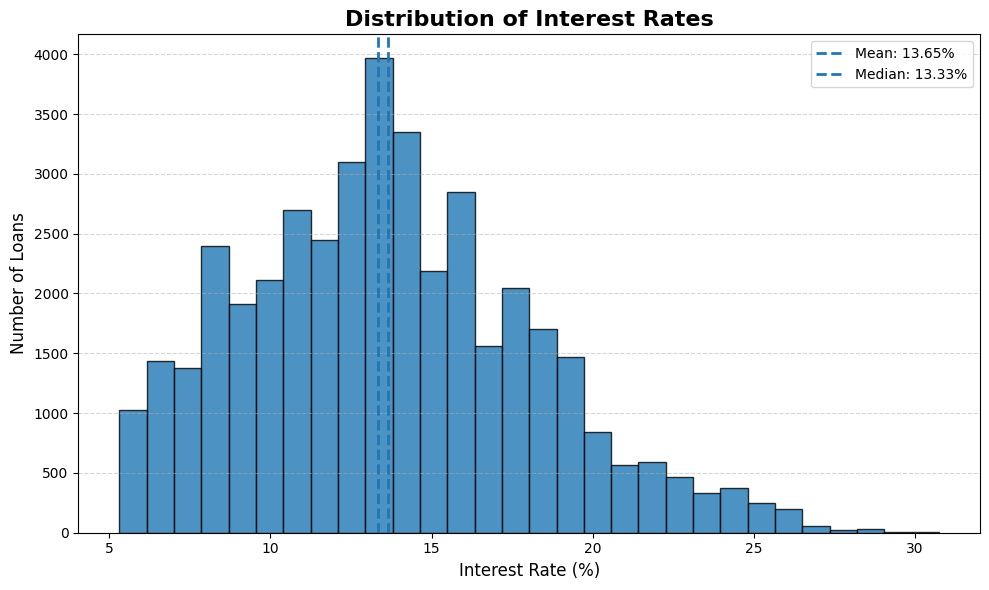

In [15]:
# Calculate the mean and median interest rates
mean_int_rate = df["int_rate"].mean()
median_int_rate = df["int_rate"].median()

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the distribution of interest rates
plt.hist(
    df["int_rate"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# Add a vertical line for the mean
plt.axvline(
    mean_int_rate,
    linestyle="--",
    linewidth=2,
    label=f"Mean: {mean_int_rate:.2f}%"
)

# Add a vertical line for the median
plt.axvline(
    median_int_rate,
    linestyle="--",
    linewidth=2,
    label=f"Median: {median_int_rate:.2f}%"
)

# Add title and axis labels
plt.title(
    "Distribution of Interest Rates",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Interest Rate (%)", fontsize=12)
plt.ylabel("Number of Loans", fontsize=12)

# Add horizontal grid lines
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Add legend
plt.legend()

# Adjust the layout
plt.tight_layout()

# Display the visualization
plt.show()

###### Interpretation

The distribution of interest rates shows that the mean interest rate is 13.64%, while the median is 13.33%. The mean being slightly higher than the median indicates a slight positive skew in the distribution. Most loans have interest rates concentrated between approximately 10% and 18%, with relatively fewer loans having higher interest rates. The distribution extends to approximately 31%, indicating variation in the interest rates offered to borrowers.

### 3.11 Loan Status by Loan Grade

The relationship between loan grade and loan status is examined to determine how loan outcomes vary across different credit grades. This analysis helps identify patterns that may be useful for predicting loan default.

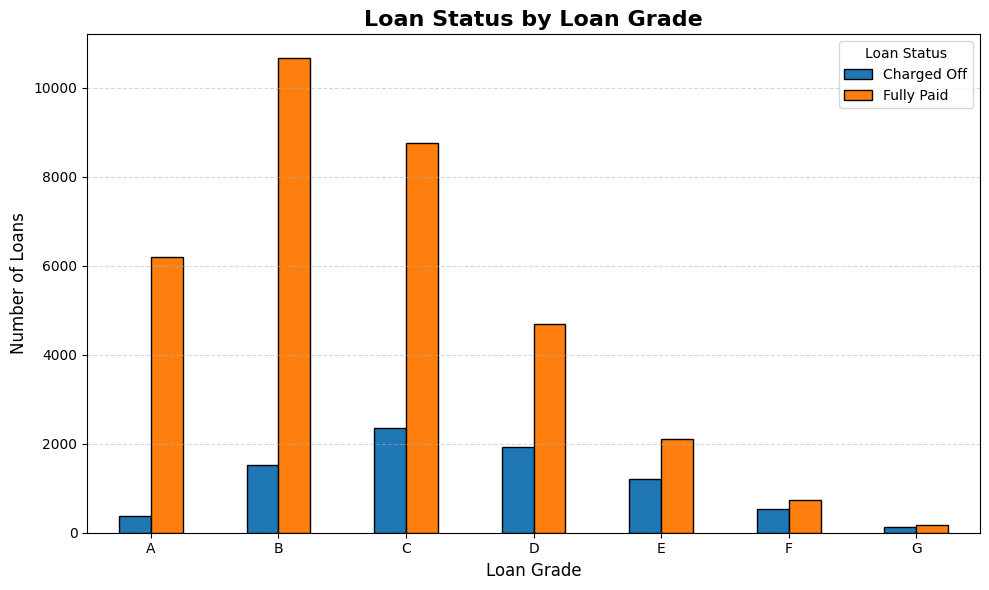

In [16]:
# Create a cross-tabulation of loan grade and loan status
grade_status = pd.crosstab(df['grade'], df['loan_status'])

# Create a bar chart showing loan status by loan grade
ax = grade_status.plot(
    kind="bar",
    figsize=(10, 6),
    edgecolor="black"
)

# Add title and axis labels
plt.title(
    "Loan Status by Loan Grade",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Loan Grade", fontsize=12)
plt.ylabel("Number of Loans", fontsize=12)

# Keep grade labels horizontal
plt.xticks(rotation=0)

# Add horizontal grid lines
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Add legend
plt.legend(
    title="Loan Status"
)

# Adjust the layout
plt.tight_layout()

# Display the visualization
plt.show()

### 3.12 Distribution of Borrowers' Annual Income

The distribution of annual income is visualized to examine the income characteristics of borrowers and identify the general spread and concentration of annual income values.

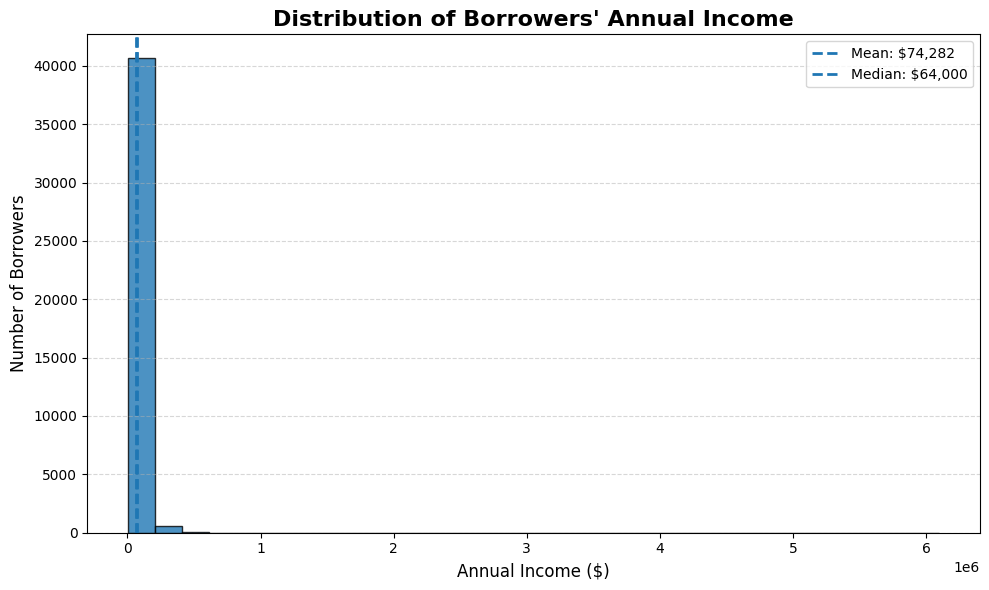

In [17]:
# Calculate the mean and median annual income
mean_income = df["annual_inc"].mean()
median_income = df["annual_inc"].median()

# Create the figure
plt.figure(figsize=(10, 6))

# Plot the distribution of annual income
plt.hist(
    df["annual_inc"].dropna(),
    bins=30,
    edgecolor="black",
    alpha=0.8
)

# Add a vertical line for the mean
plt.axvline(
    mean_income,
    linestyle="--",
    linewidth=2,
    label=f"Mean: ${mean_income:,.0f}"
)

# Add a vertical line for the median
plt.axvline(
    median_income,
    linestyle="--",
    linewidth=2,
    label=f"Median: ${median_income:,.0f}"
)

# Add title and axis labels
plt.title(
    "Distribution of Borrowers' Annual Income",
    fontsize=16,
    fontweight="bold"
)
plt.xlabel("Annual Income ($)", fontsize=12)
plt.ylabel("Number of Borrowers", fontsize=12)

# Add horizontal grid lines
plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.5
)

# Add legend
plt.legend()

# Adjust the layout
plt.tight_layout()

# Display the visualization
plt.show()

### 3.13 Box Plot Analysis of Numerical Variables

Box plots are used to examine the distribution, central tendency, spread, and potential outliers of the main numerical variables. Standardized values are used for visualization so that variables with different scales can be compared more clearly.

/tmp/ipykernel_1719/1215207398.py:35: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


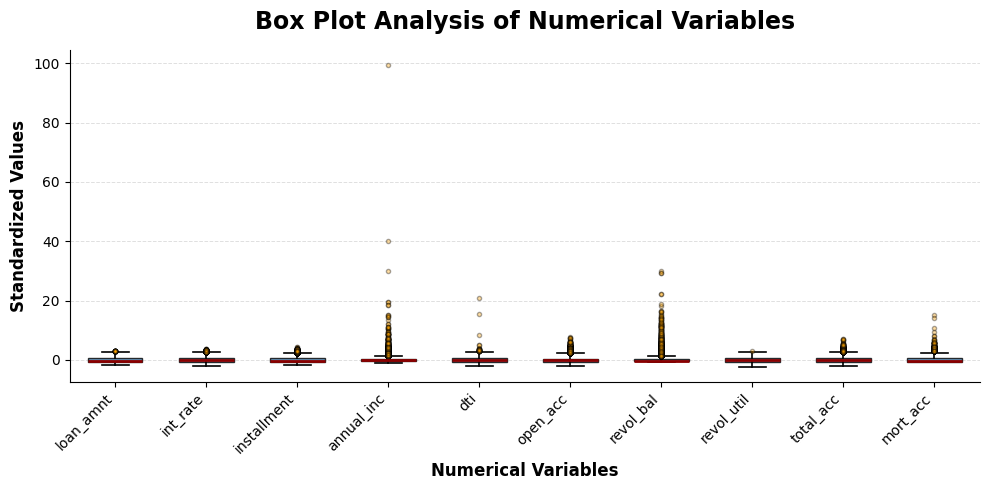

In [18]:
# Import StandardScaler for visualization scaling
from sklearn.preprocessing import StandardScaler

# Select important numerical variables for box plot analysis
boxplot_features = [
    "loan_amnt",
    "int_rate",
    "installment",
    "annual_inc",
    "dti",
    "open_acc",
    "revol_bal",
    "revol_util",
    "total_acc",
    "mort_acc"
]

# Standardize the selected numerical variables for visualization
scaler = StandardScaler()

scaled_data = scaler.fit_transform(
    df[boxplot_features].dropna()
)

# Convert the standardized data back into a DataFrame
scaled_df = pd.DataFrame(
    scaled_data,
    columns=boxplot_features
)

# Create the figure
fig, ax = plt.subplots(figsize=(10, 5))

# Create the box plots
box = ax.boxplot(
    scaled_df.values,
    labels=boxplot_features,
    patch_artist=True,
    widths=0.6,
    medianprops=dict(
        color="darkred",
        linewidth=2
    ),
    boxprops=dict(
        facecolor="steelblue",
        edgecolor="black",
        alpha=0.8
    ),
    whiskerprops=dict(
        color="black",
        linewidth=1.2
    ),
    capprops=dict(
        color="black",
        linewidth=1.2
    ),
    flierprops=dict(
        marker="o",
        markerfacecolor="orange",
        markeredgecolor="black",
        markersize=3,
        alpha=0.35
    )
)

# Add title
ax.set_title(
    "Box Plot Analysis of Numerical Variables",
    fontsize=17,
    fontweight="bold",
    pad=15
)

# Add axis labels
ax.set_xlabel(
    "Numerical Variables",
    fontsize=12,
    fontweight="bold"
)

ax.set_ylabel(
    "Standardized Values",
    fontsize=12,
    fontweight="bold"
)

# Improve x-axis readability
plt.xticks(
    rotation=45,
    ha="right",
    fontsize=10
)

# Add subtle horizontal gridlines
ax.grid(
    axis="y",
    linestyle="--",
    linewidth=0.7,
    alpha=0.4
)

# Remove unnecessary top and right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Adjust layout
plt.tight_layout()

# Display the visualization
plt.show()

### 3.14 Correlation Analysis

Correlation analysis is performed to examine the relationships between the numerical variables in the dataset. A correlation coefficient close to +1 indicates a strong positive relationship, while a coefficient close to -1 indicates a strong negative relationship. Values close to 0 indicate a weak or no linear relationship.

The correlation analysis helps identify relationships between features and potential multicollinearity that may need to be considered during feature selection.

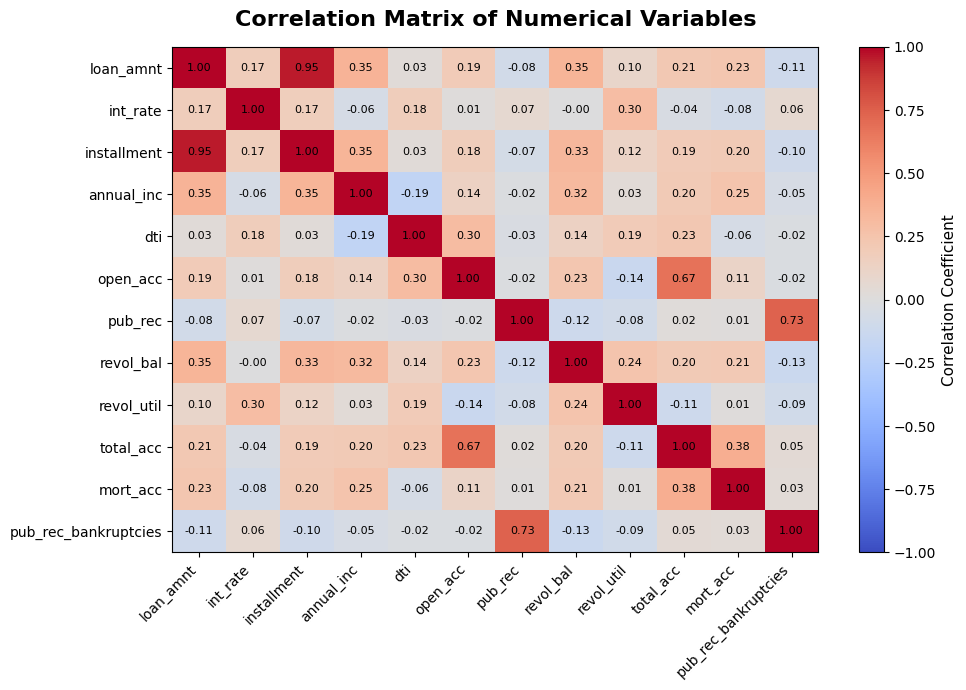

In [19]:
# Select numerical variables
correlation_data = df.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = correlation_data.corr()

# Create the figure
plt.figure(figsize=(10, 7))

# Create the heatmap
plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    aspect="auto"
)

# Add color bar
cbar = plt.colorbar()
cbar.set_label("Correlation Coefficient", fontsize=11)

# Add axis labels
plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

# Add correlation values inside the cells
for i in range(len(correlation_matrix.columns)):
    for j in range(len(correlation_matrix.columns)):
        value = correlation_matrix.iloc[i, j]

        plt.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8,
            color="black"
        )

# Add title
plt.title(
    "Correlation Matrix of Numerical Variables",
    fontsize=16,
    fontweight="bold",
    pad=15
)

# Adjust layout
plt.tight_layout()

# Display the visualization
plt.show()

# 4. Data Preprocessing and Preparation

The data preprocessing stage prepares the loan dataset for machine learning by handling missing values, removing irrelevant variables, converting categorical variables into numerical form, and ensuring that the dataset is suitable for model development.

The preprocessing steps are performed based on the findings obtained during the exploratory data analysis.

### 4.1 Create a Copy of the Dataset

A copy of the original dataset is created to preserve the raw data. All preprocessing operations will be performed on the copied dataset.

In [20]:
# Create a copy of the original dataset
df_processed = df.copy()

# Display the shape of the copied dataset
print("Dataset shape:", df_processed.shape)

Dataset shape: (41364, 27)


### 4.2 Identify Missing Values

The missing values identified during EDA are reviewed before applying appropriate preprocessing techniques.

In [21]:
# Calculate the number of missing values in each column
missing_values = df_processed.isnull().sum()

# Display only columns containing missing values
missing_values[missing_values > 0]

,0
emp_title,2364
emp_length,1900
title,166
revol_util,27
mort_acc,3825
pub_rec_bankruptcies,54
address,1


### 4.3 Handling Missing Values

Missing values identified during the exploratory data analysis are handled using appropriate techniques based on the data type and characteristics of each variable. Categorical and text variables are assigned the value `Unknown` to preserve observations without introducing an artificial category. Numerical variables are imputed using their median values because the median is less sensitive to extreme values and outliers.

For `mort_acc`, which contains a relatively large number of missing observations, a missing-value indicator is also created. This allows the machine learning models to distinguish between an actual value and an originally missing value.

The selected approach preserves as many observations as possible while reducing the risk of bias that could result from deleting rows with missing values.

In [22]:
# Fill missing values in the employment title column with "Unknown"
# because emp_title is a categorical/text variable.
df_processed['emp_title'] = df_processed['emp_title'].fillna('Unknown')


# Fill missing values in employment length with "Unknown"
# because emp_length is a categorical variable.
# This avoids assuming a particular employment length for missing records.
df_processed['emp_length'] = df_processed['emp_length'].fillna('Unknown')


# Fill missing values in the loan title column with "Unknown"
# because title is a text/categorical variable.
df_processed['title'] = df_processed['title'].fillna('Unknown')


# Create a binary indicator showing whether mort_acc was originally missing.
# 1 means the original value was missing, while 0 means it was available.
df_processed['mort_acc_missing'] = df_processed['mort_acc'].isnull().astype(int)


# Calculate the median of revol_util.
# The median is used because it is less affected by extreme values.
revol_util_median = df_processed['revol_util'].median()


# Replace missing revol_util values with the calculated median.
df_processed['revol_util'] = df_processed['revol_util'].fillna(
    revol_util_median
)


# Calculate the median of mort_acc.
# This provides a robust estimate for the missing numerical values.
mort_acc_median = df_processed['mort_acc'].median()


# Replace missing mort_acc values with its median.
df_processed['mort_acc'] = df_processed['mort_acc'].fillna(
    mort_acc_median
)


# Calculate the median of pub_rec_bankruptcies.
pub_rec_bankruptcies_median = df_processed['pub_rec_bankruptcies'].median()


# Replace missing pub_rec_bankruptcies values with its median.
df_processed['pub_rec_bankruptcies'] = df_processed[
    'pub_rec_bankruptcies'
].fillna(pub_rec_bankruptcies_median)

###### 4.3.1 Verification of Missing Values

After applying the selected missing-value treatment techniques, the dataset is re-examined to verify that the missing values have been successfully handled. This step ensures that no missing values remain in the dataset before proceeding to the subsequent preprocessing stages.

The number of remaining missing values is first calculated for each column. Only columns that still contain missing values are displayed.

In [23]:
# Calculate the number of missing values in each column
remaining_missing = df_processed.isnull().sum()

# Display only columns that still contain missing values
remaining_missing[remaining_missing > 0]

,0
address,1


###### The verification confirms that no missing values remain in the dataset. Therefore, the missing-value preprocessing step has been successfully completed, and the dataset is ready for the next preprocessing stage.

### 4.4 Identify Duplicate Records

Duplicate records are identified to determine whether identical observations occur more than once in the dataset. Duplicate observations may introduce bias into the machine learning models by giving repeated records greater influence during model training. Therefore, duplicate records are examined before proceeding with further preprocessing.

In [24]:
# Identify duplicate rows in the processed dataset
duplicates = df_processed.duplicated()

# Count the total number of duplicate rows
duplicate_count = duplicates.sum()

# Display the number of duplicate rows
print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


###### No duplicate records were found.

### 4.5 Check Data Types

The data types of all variables are examined to ensure that each variable is stored in an appropriate format. Correct data types are important because they determine how the variables will be processed during feature encoding, feature selection, and model training.

Numerical variables should be stored as numerical data types, while categorical and text variables should be stored as categorical or object types. Any variables stored using inappropriate data types will be identified and converted where necessary.

In [25]:
# Display the data type of each column
df_processed.dtypes

,0
loan_amnt,float64
term,object
int_rate,float64
installment,float64
grade,object
sub_grade,object
emp_title,object
emp_length,object
home_ownership,object
annual_inc,float64


###### 4.5.1 Verification of Data Types

The inspection confirmed that the variables were stored using appropriate data types. Numerical variables were correctly represented as numerical data, while categorical and text variables were correctly represented as object or categorical data.

Since all variables were correctly typed, no data type conversion was necessary.

### 4.6 Invalid Values / Data Consistency

The dataset was examined for invalid and inconsistent values that could affect the accuracy of the loan default prediction model. Numerical variables were checked to ensure that their values fell within reasonable ranges, while categorical variables were examined for inconsistent or unexpected entries.

This step is important because invalid values may represent data-entry errors, incorrect measurements, or inconsistencies in the original dataset. Such values can negatively affect the preprocessing and modelling stages.

The identified variables were therefore assessed based on their expected characteristics before proceeding to feature selection and model development.

#### 4.6.1 Check Numerical Variables

Numerical variables were examined to identify values that are logically invalid, such as negative loan amounts, negative income, or negative account counts. Variables representing percentages were also checked to determine whether their values fall within their expected ranges.

In [26]:
# Display the minimum value of selected numerical variables
# to identify possible negative or invalid values
df_processed[
    [
        'loan_amnt',
        'int_rate',
        'installment',
        'annual_inc',
        'open_acc',
        'pub_rec',
        'revol_bal',
        'revol_util',
        'total_acc',
        'mort_acc',
        'pub_rec_bankruptcies'
    ]
].min()

,0
loan_amnt,500.00
int_rate,5.32
installment,16.31
annual_inc,2500.00
open_acc,0.00
pub_rec,0.00
revol_bal,0.00
revol_util,0.00
total_acc,2.00
mort_acc,0.00


###### Interpretation of Numerical Value Checks

The minimum-value analysis showed that the numerical variables did not contain negative values. The minimum loan amount, interest rate, and installment were all positive, while variables such as public records, revolving balance, mortgage accounts, and bankruptcies had valid minimum values of zero.

The annual income variable had a minimum value of zero. Although zero annual income is unusual for a loan applicant, it does not automatically indicate an invalid observation. Therefore, these records were further examined before making any decision to remove or modify them.

Overall, the numerical value check did not identify any clearly invalid values requiring immediate removal.

In [27]:
# Display the maximum value of selected numerical variables
# to identify unusually large or out-of-range values
df_processed[
    [
        'loan_amnt',
        'int_rate',
        'installment',
        'annual_inc',
        'open_acc',
        'pub_rec',
        'revol_bal',
        'revol_util',
        'total_acc',
        'mort_acc',
        'pub_rec_bankruptcies'
    ]
].max()

,0
loan_amnt,40000.00
int_rate,30.74
installment,1533.81
annual_inc,6100000.00
open_acc,51.00
pub_rec,11.00
revol_bal,617838.00
revol_util,129.40
total_acc,111.00
mort_acc,34.00


###### Interpretation of Maximum Numerical Values

The maximum-value analysis showed that several numerical variables contained relatively large values. The maximum loan amount was 40,000, while the maximum annual income was 8,706,582. These values are high but may represent genuine differences among borrowers and were therefore not automatically treated as invalid.

Similarly, variables such as `open_acc`, `pub_rec`, `revol_bal`, `total_acc`, `mort_acc`, and `pub_rec_bankruptcies` contained high maximum values. These observations require consideration during exploratory data analysis but cannot be classified as errors based on their magnitude alone.

The `revol_util` variable had a maximum value of 892.30. Since revolving utilization is generally represented as a percentage, values above 100% require further investigation to determine whether they represent valid observations or potential data-quality issues.

Therefore, extreme values were not automatically removed. Instead, potentially invalid values were identified for further investigation, while legitimate extreme observations were retained to avoid unnecessary loss of information.

### 4.7 Outlier Detection and Treatment

Outlier detection was performed to identify observations with unusually high or low numerical values compared with the majority of the dataset. Outliers are important in loan default prediction because extreme financial characteristics, such as very high income, loan amounts, or revolving balances, may influence the modelling process.

The Interquartile Range (IQR) method was used to identify potential outliers in the numerical variables. The IQR method defines an observation as a potential outlier when it falls below the lower bound or above the upper bound.

However, an identified outlier is not automatically considered an invalid observation. In financial datasets, extreme values may represent genuine borrower characteristics. Therefore, the identified observations were investigated before deciding whether any treatment was necessary.

#### 4.7.1 Identification of Potential Outliers Using IQR

The Interquartile Range (IQR) method was used to identify potential outliers in the numerical variables. The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1).

The lower and upper bounds were calculated using:

\[
Lower\ Bound = Q1 - 1.5(IQR)
\]

\[
Upper\ Bound = Q3 + 1.5(IQR)
\]

Observations outside these bounds were classified as potential outliers for further investigation.

In [28]:
# Select all numerical columns
numeric_columns = df_processed.select_dtypes(include='number').columns

# Calculate the first quartile (Q1)
Q1 = df_processed[numeric_columns].quantile(0.25)

# Calculate the third quartile (Q3)
Q3 = df_processed[numeric_columns].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Calculate the lower outlier boundary
lower_bound = Q1 - 1.5 * IQR

# Calculate the upper outlier boundary
upper_bound = Q3 + 1.5 * IQR

# Count potential outliers in each numerical variable
outlier_counts = (
    (df_processed[numeric_columns] < lower_bound) |
    (df_processed[numeric_columns] > upper_bound)
).sum()

# Display variables containing potential outliers
outlier_counts[outlier_counts > 0].sort_values(ascending=False)

,0
pub_rec,6024
pub_rec_bankruptcies,4719
mort_acc_missing,3825
revol_bal,2318
annual_inc,1753
installment,1184
open_acc,1045
total_acc,863
mort_acc,703
int_rate,318


#### 4.7.2 Handling of Outliers

The potential outliers identified using the Interquartile Range (IQR) method were evaluated before applying any treatment. The analysis showed that several numerical variables contained a relatively large number of potential outliers. However, these observations do not necessarily represent errors.

In the loan dataset, extreme values may represent genuine borrower characteristics. For example, a borrower may have a high annual income, large revolving balance, many credit accounts, or a high number of public records. Automatically removing such observations could result in the loss of important information and reduce the size and representativeness of the dataset.

Therefore, blanket removal of IQR-based outliers was not applied. Similarly, automatic capping of all extreme values was avoided because it could alter genuine financial information.

The identified extreme observations were instead evaluated according to the logical range and meaning of each variable. Values that were plausible and represented genuine borrower characteristics were retained. Only observations confirmed to be logically impossible or resulting from data-entry errors would be corrected or removed.

This approach is also appropriate for the selected Random Forest and XGBoost algorithms because tree-based models do not require numerical variables to be normally distributed and are generally less sensitive to extreme numerical values than distance-based or linear models.

### 4.8 Feature Encoding

Feature encoding was performed to convert categorical variables into numerical representations that can be processed by the machine learning models. Label Encoding was used to transform categorical values into numerical labels. This approach allows the categorical variables to be represented numerically while preserving the distinct categories within each variable.

The encoding was applied to the categorical predictor variables, while numerical variables were retained in their original numerical form. The target variable, `loan_status`, was also encoded into numerical labels for use during model training.

In [29]:
# Import the LabelEncoder from scikit-learn
from sklearn.preprocessing import LabelEncoder

# Create a copy of the processed dataset before encoding
df_encoded = df_processed.copy()

# Create a LabelEncoder object
label_encoder = LabelEncoder()


# ---------------------------------------------------------
# 1. Encode the TERM variable
# ---------------------------------------------------------

# Convert the loan term from text to numerical values
# Example: "36 months" becomes 36 and "60 months" becomes 60
df_encoded['term'] = (
    df_encoded['term']
    .str.extract(r'(\d+)')
    .astype(int)
)


# ---------------------------------------------------------
# 2. Encode GRADE
# ---------------------------------------------------------

# Define the order of loan grades
grade_mapping = {
    'A': 1,
    'B': 2,
    'C': 3,
    'D': 4,
    'E': 5,
    'F': 6,
    'G': 7
}

# Apply the grade mapping
df_encoded['grade'] = df_encoded['grade'].map(grade_mapping)


# ---------------------------------------------------------
# 3. Encode SUB-GRADE
# ---------------------------------------------------------

# Create an ordered mapping for sub-grades
# A1 = 1, A2 = 2, ..., G5 = 35
sub_grade_mapping = {}

# Start the numerical encoding at 1
value = 1

# Loop through grades A to G
for grade in ['A', 'B', 'C', 'D', 'E', 'F', 'G']:

    # Loop through sub-grades 1 to 5
    for number in range(1, 6):

        # Create the sub-grade label
        sub_grade = grade + str(number)

        # Assign a numerical value
        sub_grade_mapping[sub_grade] = value

        # Increase the value for the next sub-grade
        value += 1

# Apply the sub-grade mapping
df_encoded['sub_grade'] = df_encoded['sub_grade'].map(
    sub_grade_mapping
)


# ---------------------------------------------------------
# 4. Encode EMPLOYMENT LENGTH
# ---------------------------------------------------------

# Define numerical values for employment length
emp_length_mapping = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10,
    'Unknown': -1
}

# Apply the employment-length mapping
df_encoded['emp_length'] = df_encoded['emp_length'].map(
    emp_length_mapping
)


# ---------------------------------------------------------
# 5. Encode NOMINAL CATEGORICAL VARIABLES
# ---------------------------------------------------------

# List the remaining categorical predictor variables
categorical_columns = [
    'home_ownership',
    'verification_status',
    'purpose',
    'initial_list_status',
    'application_type'
]

# Apply Label Encoding to each categorical variable
for column in categorical_columns:

    # Convert the values in the column into numerical labels
    df_encoded[column] = label_encoder.fit_transform(
        df_encoded[column].astype(str)
    )


# ---------------------------------------------------------
# 6. Encode DATE VARIABLES
# ---------------------------------------------------------

# Convert the issue date into datetime format
df_encoded['issue_d'] = pd.to_datetime(
    df_encoded['issue_d'],
    format='%b-%Y'
)

# Extract the year from the issue date
df_encoded['issue_year'] = df_encoded['issue_d'].dt.year

# Extract the month from the issue date
df_encoded['issue_month'] = df_encoded['issue_d'].dt.month


# Convert the earliest credit-line date into datetime format
df_encoded['earliest_cr_line'] = pd.to_datetime(
    df_encoded['earliest_cr_line'],
    format='%b-%Y'
)

# Extract the year of the earliest credit line
df_encoded['earliest_cr_line_year'] = (
    df_encoded['earliest_cr_line'].dt.year
)

# Calculate the approximate credit history in years
df_encoded['credit_history_years'] = (
    df_encoded['issue_year']
    - df_encoded['earliest_cr_line_year']
)

# Remove the original date columns
df_encoded.drop(
    columns=[
        'issue_d',
        'earliest_cr_line',
        'earliest_cr_line_year'
    ],
    inplace=True
)


# ---------------------------------------------------------
# 7. HANDLE HIGH-CARDINALITY TEXT VARIABLES
# ---------------------------------------------------------

# Remove variables with a very large number of unique values
# to prevent the creation of an unnecessarily large feature space
df_encoded.drop(
    columns=['emp_title', 'title', 'address'],
    inplace=True
)


# ---------------------------------------------------------
# 8. ENCODE THE TARGET VARIABLE
# ---------------------------------------------------------

# Display the loan-status categories before encoding
print("Loan status categories:")
print(df_encoded['loan_status'].unique())

# Encode the target variable using Label Encoding
df_encoded['loan_status'] = label_encoder.fit_transform(
    df_encoded['loan_status'].astype(str)
)


# ---------------------------------------------------------
# 9. VERIFY THE ENCODING
# ---------------------------------------------------------

# Display the data types after encoding
print("\nData types after encoding:")
print(df_encoded.dtypes)

# Check for any remaining categorical columns
remaining_categorical = df_encoded.select_dtypes(
    include='object'
).columns

# Display remaining categorical columns
print("\nRemaining categorical columns:")
print(remaining_categorical)

# Display the first five rows of the encoded dataset
print("\nEncoded dataset:")
display(df_encoded.head())

Loan status categories:
['Fully Paid' 'Charged Off']

Data types after encoding:
loan_amnt               float64
term                      int64
int_rate                float64
installment             float64
grade                     int64
sub_grade                 int64
emp_length                int64
home_ownership            int64
annual_inc              float64
verification_status       int64
loan_status               int64
purpose                   int64
dti                     float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status       int64
application_type          int64
mort_acc                float64
pub_rec_bankruptcies    float64
mort_acc_missing          int64
issue_year                int32
issue_month               int32
credit_history_years      int32
dtype: object

Remaining categorical columns:
Index([], dtype='object')

Encoded datase

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,...,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,mort_acc_missing,issue_year,issue_month,credit_history_years
0,10000.0,36,11.44,329.48,2,9,10,5,117000.0,0,...,41.8,25.0,1,1,0.0,0.0,0,2015,1,25
1,8000.0,36,11.99,265.68,2,10,4,1,65000.0,0,...,53.3,27.0,0,1,3.0,0.0,0,2015,1,11
2,15600.0,36,10.49,506.97,2,8,0,5,43057.0,1,...,92.2,26.0,0,1,0.0,0.0,0,2015,1,8
3,7200.0,36,6.49,220.65,1,2,6,5,54000.0,0,...,21.5,13.0,0,1,0.0,0.0,0,2014,11,8
4,24375.0,60,17.27,609.33,3,15,9,1,55000.0,2,...,69.8,43.0,0,1,1.0,0.0,0,2013,4,14


###### Verification of Feature Encoding

After applying Label Encoding, the categorical variables were converted into numerical representations. The original date variables were transformed into meaningful numerical features, including loan issue year, issue month, and credit history length. High-cardinality text variables were excluded to avoid generating an unnecessarily large number of features.

The encoded dataset was then examined to verify that the variables were stored in appropriate numerical formats and that no unintended categorical variables remained.

### 5. Feature Selection and Feature Importance


## 5. Feature Selection and Feature Importance

Feature selection is the process of identifying the most relevant variables for predicting loan default. Selecting relevant features can reduce unnecessary information, improve model efficiency, and simplify the machine learning model.

In this study, feature importance was used to identify the variables that contribute most to loan default prediction. A Random Forest model was used to calculate the importance of each feature because it can evaluate the contribution of multiple variables and capture non-linear relationships.

The feature importance results were then used to identify the most relevant features for the subsequent machine learning modelling stage.

In [30]:
# Create a copy of the encoded dataset
data = df_encoded.copy()

# Separate the target variable from the predictor variables
X = data.drop(columns=['loan_status'])

# Store the target variable
y = data['loan_status']

# Display the shape of the predictor dataset
print("Features shape:", X.shape)

# Display the shape of the target variable
print("Target shape:", y.shape)

Features shape: (41364, 25)
Target shape: (41364,)


### 6. Split the Dataset into Training and Testing Sets

The dataset was divided into training and testing sets to evaluate the performance of the machine learning models on unseen data. The training set was used to train the models, while the testing set was reserved for evaluating their predictive performance.

An 80:20 ratio was used, where 80% of the observations were allocated to the training set and 20% to the testing set. Stratified sampling was applied to maintain the distribution of the target classes in both datasets. A random state was also specified to ensure that the same split can be reproduced.

In [31]:

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the size of the training data
print("Training features:", X_train.shape)

# Display the size of the testing data
print("Testing features:", X_test.shape)

Training features: (33091, 25)
Testing features: (8273, 25)


### 6.2 Calculate Feature Importance

Feature importance was calculated to determine the contribution of each predictor variable to the loan default prediction task. A Random Forest model was trained using the training dataset, and the importance score of each feature was obtained from the trained model.

The features were then ranked according to their importance scores, with higher values indicating a greater contribution to the model's predictions. The feature importance results were used to identify the most relevant variables for subsequent model development and feature selection.

In [32]:

# Create a Random Forest model for feature importance analysis
rf_importance = RandomForestClassifier(
    n_estimators=100,      # Number of trees in the forest
    random_state=42,       # Ensures reproducible results
    n_jobs=-1              # Uses all available CPU cores
)

# Train the Random Forest using only the training data
rf_importance.fit(X_train, y_train)

# Get the importance score of each feature
feature_importance = rf_importance.feature_importances_

# Create a DataFrame containing feature names and importance scores
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': feature_importance
})

# Sort features from the most important to the least important
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Reset the index
importance_df.reset_index(drop=True, inplace=True)

# Display the feature importance results
importance_df

,Feature,Importance
0,dti,0.085005
1,revol_util,0.076320
2,revol_bal,0.076273
3,annual_inc,0.074251
4,installment,0.071213
5,int_rate,0.070467
6,total_acc,0.060654
7,credit_history_years,0.058681
8,loan_amnt,0.058470
9,open_acc,0.051862


#### 6.3 Visualization of Feature Importance

The feature importance scores were visualized using a horizontal bar chart to provide a clear comparison of the contribution of the most important features. The visualization ranks the features from the highest to the lowest importance score, making it easier to identify the variables that contribute most to the loan default prediction.

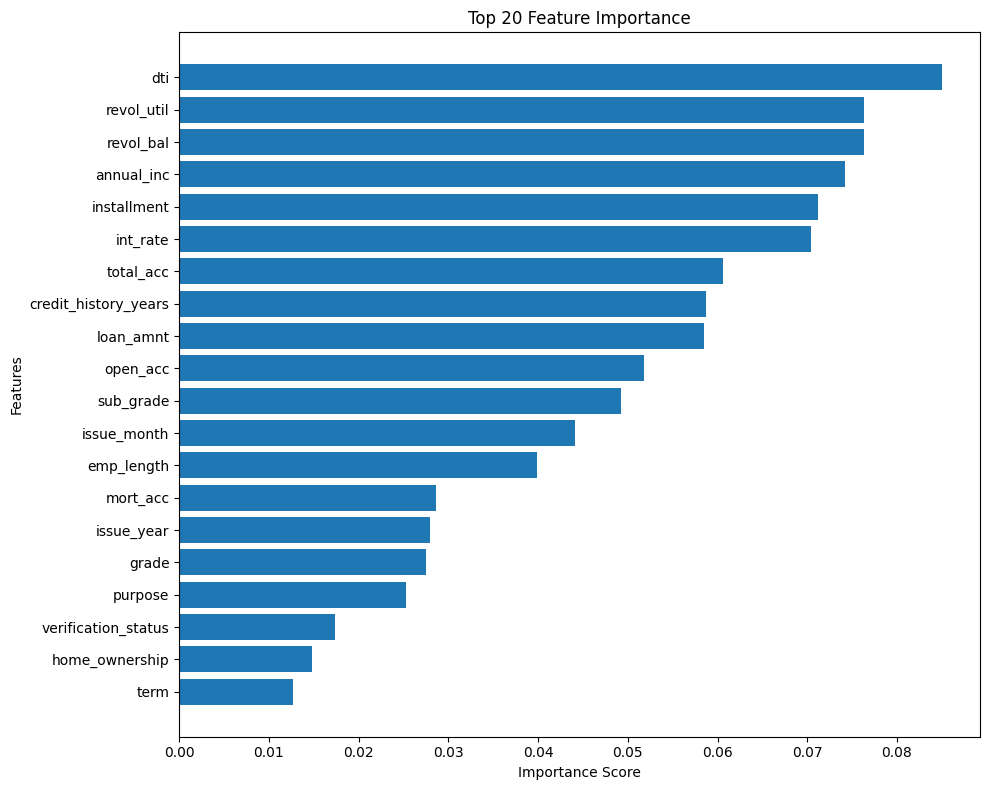

In [33]:
# Select the top 20 most important features
top_features = importance_df.head(20)

# Create the figure
plt.figure(figsize=(10, 8))

# Create a horizontal bar chart
plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

# Add the chart title
plt.title('Top 20 Feature Importance')

# Label the x-axis
plt.xlabel('Importance Score')

# Label the y-axis
plt.ylabel('Features')

# Adjust the layout
plt.tight_layout()

# Display the chart
plt.show()

###### Interpretation of Feature Importance

The results show that `dti` is the most important feature for predicting loan default, followed by `revol_bal`, `revol_util`, and `annual_inc`. Other important features include `installment`, `int_rate`, `total_acc`, and `credit_history_years`.

Variables such as `verification_status`, `home_ownership`, and `term` have relatively lower importance. Overall, debt levels, credit utilization, income, and credit history are among the most influential factors in the model.

#### 6.4 Feature Selection

A minimum feature-importance threshold of 0.01 was applied to select the most relevant features. Features with an importance score of at least 0.01 were retained for model development, while features below this threshold were excluded.

This approach reduces the number of features while retaining variables that provide meaningful information for predicting loan default.

In [35]:
# Set the minimum importance threshold
importance_threshold = 0.01

# Select features with importance scores of at least 0.01
selected_features = importance_df[
    importance_df['Importance'] >= importance_threshold
]['Feature'].tolist()

# Display the number of selected features
print("Number of selected features:", len(selected_features))

# Display the selected features
print("\nSelected features:")
print(selected_features)

Number of selected features: 21

Selected features:
['dti', 'revol_util', 'revol_bal', 'annual_inc', 'installment', 'int_rate', 'total_acc', 'credit_history_years', 'loan_amnt', 'open_acc', 'sub_grade', 'issue_month', 'emp_length', 'mort_acc', 'issue_year', 'grade', 'purpose', 'verification_status', 'home_ownership', 'term', 'initial_list_status']


### 6.5 Create Training and Testing Datasets Using Selected Features

The selected features identified during the feature selection process were used to create the final training and testing datasets. The training dataset contains the selected features used to train the machine learning models, while the testing dataset contains the same features used to evaluate the models on unseen data.

The shapes of both datasets were displayed to verify that the selected features were correctly applied.

In [39]:
# Create the training dataset using the selected features
X_train_selected = X_train[selected_features]

# Create the testing dataset using the selected features
X_test_selected = X_test[selected_features]

# Display the shape of the selected training data
print("Training data shape:", X_train_selected.shape)

# Display the shape of the selected testing data
print("Testing data shape:", X_test_selected.shape)

Training data shape: (33091, 21)
Testing data shape: (8273, 21)


### 7. Choose the Machine Learning Models

Two machine learning algorithms were selected for loan default prediction: Random Forest and XGBoost. These models were chosen because they are tree-based ensemble learning algorithms that can capture complex and non-linear relationships between borrower characteristics and loan default outcomes.

Random Forest combines multiple decision trees to improve prediction performance and reduce overfitting. XGBoost builds decision trees sequentially, where each new tree focuses on correcting the errors made by previous trees.

The two models will be trained using the same training dataset and evaluated using the same testing dataset to allow their predictive performance to be compared.

### 7.2 Random Forest Model

The Random Forest classifier was selected as the first machine learning model. It combines multiple decision trees to improve prediction accuracy and reduce overfitting. The model is suitable for loan default prediction because it can handle complex relationships between the selected features and the target variable.

In [36]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,      # Number of decision trees
    random_state=42,       # Ensures reproducible results
    n_jobs=-1              # Uses all available CPU cores
)

# Display the model configuration
rf_model

RandomForestClassifier(n_jobs=-1, random_state=42)

### 7.3 XGBoost Model

The XGBoost classifier was selected as the second machine learning model. It builds decision trees sequentially, with each new tree focusing on correcting the errors made by previous trees. This allows XGBoost to effectively capture complex patterns and improve predictive performance.

In [37]:
# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=100,      # Number of boosting trees
    learning_rate=0.1,     # Learning rate
    max_depth=6,           # Maximum depth of each tree
    random_state=42,       # Ensures reproducible results
    n_jobs=-1,             # Uses all available CPU cores
    eval_metric='logloss'  # Evaluation metric
)

# Display the model configuration
xgb_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)

### 8. Train the Machine Learning Models

The selected Random Forest and XGBoost models were trained using the training dataset containing the features identified during the feature selection process. The models were fitted using `X_train_selected` and `y_train`.

The Random Forest model learns by constructing multiple decision trees, while the XGBoost model builds trees sequentially to improve prediction errors. After training, the models are ready to make predictions on the unseen testing dataset.

### 8.1 Train the Random Forest Model

The Random Forest classifier was trained using the selected training features and the corresponding target values.

In [40]:
# Train the Random Forest model
rf_model.fit(
    X_train_selected,
    y_train
)

# Display a confirmation message
print("Random Forest model training completed.")

Random Forest model training completed.


### 8.2 Train the XGBoost Model

The XGBoost classifier was trained using the same selected training features and target values. Using the same training data allows the performance of the two models to be compared fairly.

In [41]:
# Train the XGBoost model
xgb_model.fit(
    X_train_selected,
    y_train
)

# Display a confirmation message
print("XGBoost model training completed.")

XGBoost model training completed.


### 8.3 Verify the Trained Models

Both models were successfully trained and are now ready to generate predictions using the testing dataset.

In [42]:
# Verify that both models have been trained
print("Random Forest:", rf_model)
print("\nXGBoost:", xgb_model)

Random Forest: RandomForestClassifier(n_jobs=-1, random_state=42)

XGBoost: XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=-1,
              num_parallel_tree=None, ...)


### 9. Make Predictions

After training the Random Forest and XGBoost models, predictions were generated using the testing dataset. The testing dataset was not used during model training, allowing the models to be evaluated on unseen observations.

Both models were used to predict the loan status of the borrowers in the testing dataset. The predicted values will be used in the next section to evaluate and compare the performance of the two models.

### 9.1 Random Forest Predictions

The trained Random Forest model was used to predict the loan status of borrowers in the testing dataset.

In [43]:
# Make predictions using the Random Forest model
y_pred_rf = rf_model.predict(X_test_selected)

# Display the first 10 predictions
print("Random Forest predictions:")
print(y_pred_rf[:10])

Random Forest predictions:
[1 1 1 1 1 1 1 1 1 1]


### 9.2 XGBoost Predictions

The trained XGBoost model was used to predict the loan status of borrowers in the testing dataset.

In [45]:
# Make predictions using the XGBoost model
y_pred_xgb = xgb_model.predict(X_test_selected)

# Display the first 10 predictions
print("XGBoost predictions:")
print(y_pred_xgb[:10])

XGBoost predictions:
[1 1 1 1 1 1 1 1 1 1]
